<a href="https://colab.research.google.com/github/tonHS/Cyclistic-July-2026/blob/main/Cyclistic_Capstone_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# Install Dependencies and Packages
# ============================================================================
!pip install stats-can openpyxl

import pandas as pd
import requests
import zipfile
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import stats_can
import glob

In [2]:
# =============================================================================
# Merge spreadsheets into a single clean file
# =============================================================================

# Access 12 months of bike ride csv spreadsheets in Google Drive: https://drive.google.com/drive/folders/1CiHjC_-Ufwj_nG2P-o85X4JvuE1ZMo7j?usp=drive_link

from google.colab import drive
drive.mount('/content/drive')

files = glob.glob('/content/drive/MyDrive/Capstone_Cyclistic_July2026/Cyclistic July 2026/*.csv')[:12] # Limiting to the first 12 files
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
print(f"The table has {df.shape[0]} rows and {df.shape[1]} columns.")


Mounted at /content/drive
The table has 5932349 rows and 13 columns.


In [3]:
# Looking at new file to make sure the data looks reasonable and reflects correct start month

display(df.head())

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,41.932225,-87.658617,41.946176,-87.673308,member
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,41.822985,-87.607100,41.809855,-87.606755,member
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,41.926277,-87.630834,41.968812,-87.657659,member
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,41.949473,-87.646453,41.968812,-87.657659,member
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,41.926277,-87.630834,41.936253,-87.652662,member


In [4]:
# Looking at new file to make sure the data looks reasonable and reflects correct end month

display(df.tail())

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
5932344,86932262232F29F0,electric_bike,2026-06-17 21:09:10.026,2026-06-17 21:15:09.708,Clark St & Lincoln Ave,CHI00413,NaN,NaN,41.915689,-87.634600,41.930000,-87.640000,member
5932345,6654F4B0FC4D361E,classic_bike,2026-06-07 08:07:09.330,2026-06-07 08:09:11.320,California Ave & Cortez St,CHI00700,California Ave & Division St,CHI00340,41.900363,-87.696704,41.903029,-87.697474,member
5932346,6A71125A045366A8,electric_bike,2026-06-02 15:36:13.487,2026-06-02 15:47:10.902,Monticello Ave & Diversey Ave,CHI02190,NaN,NaN,41.931720,-87.718460,41.950000,-87.710000,member
5932347,152C05EEB9316CD6,electric_bike,2026-06-10 15:55:03.821,2026-06-10 16:03:57.409,Leavitt St & Addison St,CHI00529,NaN,NaN,41.946655,-87.683359,41.950000,-87.710000,member
5932348,FAC7317471AB6A4C,electric_bike,2026-06-10 14:47:35.964,2026-06-10 15:01:45.676,Clark St & Lincoln Ave,CHI00413,NaN,NaN,41.915689,-87.634600,41.900000,-87.630000,member


In [5]:
# Look at the new file for data type and quick list of columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5932349 entries, 0 to 5932348
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 588.4+ MB


In [6]:
# Cleaning out unnecessary columns so that the new file is easier to work with

df_all = df[[
    'ride_id',
    'rideable_type',
    'started_at',
    'ended_at',
    'start_station_name',
    'start_station_id',
    'end_station_name',
    'end_station_id',
    'member_casual'
]]

df_all.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,member
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,member
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,member
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,member
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,member


In [7]:
# Check for duplicates based on 'ride_id' and remove them
num_initial_rows = df_all.shape[0]
num_unique_rides_before_dedup = df_all['ride_id'].nunique()

print(f"Initial rows in df_all: {num_initial_rows}")
print(f"Unique rides in df_all before deduplication: {num_unique_rides_before_dedup}")

# Remove duplicate rides based on 'ride_id', keeping the first occurrence
df_all = df_all.drop_duplicates(subset=['ride_id'])

num_final_rows = df_all.shape[0]
num_unique_rides_after_dedup = df_all['ride_id'].nunique()

print(f"Rows in df_all after deduplication: {num_final_rows}")
print(f"Unique rides in df_all after deduplication: {num_unique_rides_after_dedup}")

# Recreate df_casual and df_member from the deduplicated df_all
df_casual = df_all[df_all['member_casual'] == 'casual'].copy()
df_member = df_all[df_all['member_casual'] == 'member'].copy()

print(f"Rows in df_casual after deduplication: {df_casual.shape[0]}")
print(f"Rows in df_member after df_all deduplication: {df_member.shape[0]}")
print(f"Unique rides in df_casual after deduplication: {df_casual['ride_id'].nunique()}")
print(f"Unique rides in df_member after deduplication: {df_member['ride_id'].nunique()}")

Initial rows in df_all: 5932349
Unique rides in df_all before deduplication: 5932314
Rows in df_all after deduplication: 5932314
Unique rides in df_all after deduplication: 5932314
Rows in df_casual after deduplication: 2116622
Rows in df_member after df_all deduplication: 3815692
Unique rides in df_casual after deduplication: 2116622
Unique rides in df_member after deduplication: 3815692


In [8]:
# =============================================================================
# Casual and Member Rides - Initial Metrics
# =============================================================================

# Casual vs member rides all year

df_casual = df_all[df_all['member_casual'] == 'casual'].copy()
print(f"The casual-only data frame has {df_casual.shape[0]} rows.")
df_unique_casual = df_casual['ride_id'].nunique()
print(f"The casual-only data frame has {df_unique_casual} unique rides.")

df_member = df_all[df_all['member_casual'] == 'member'].copy()
print(f"The member-only data frame has {df_member.shape[0]} rows.")
df_unique_member = df_member['ride_id'].nunique()
print(f"The member-only data frame has {df_unique_member} unique rides.")

df_unique_all = df_all['ride_id'].nunique()
print(f"The all-data frame has {df_unique_all} unique rides.")

print(f"In the past 12 months, {round(df_unique_casual/df_unique_all, 2)} of all unique rides were casual.")
print(f"In the past 12 months, {round(df_unique_member/df_unique_all, 2)} of all unique rides were members.")


The casual-only data frame has 2116622 rows.
The casual-only data frame has 2116622 unique rides.
The member-only data frame has 3815692 rows.
The member-only data frame has 3815692 unique rides.
The all-data frame has 5932314 unique rides.
In the past 12 months, 0.36 of all unique rides were casual.
In the past 12 months, 0.64 of all unique rides were members.


In [9]:
# Casual and member rides by months and day of the week. Looking for trends like summer vs winter use and weekend vs weekday

df_casual['started_at'] = pd.to_datetime(df_casual['started_at'])
df_casual['ended_at'] = pd.to_datetime(df_casual['ended_at'])

df_member['started_at'] = pd.to_datetime(df_member['started_at'])
df_member['ended_at'] = pd.to_datetime(df_member['ended_at'])


In [10]:
# Start time, day and month trends

# Extract month, day of the week, and hour for casual riders
df_casual['start_month'] = df_casual['started_at'].dt.month_name()
df_casual['start_day_of_week'] = df_casual['started_at'].dt.day_name()
df_casual['start_hour'] = df_casual['started_at'].dt.hour

# Extract month, day of the week, and hour for member riders
df_member['start_month'] = df_member['started_at'].dt.month_name()
df_member['start_day_of_week'] = df_member['started_at'].dt.day_name()
df_member['start_hour'] = df_member['started_at'].dt.hour

print("Casual rides DataFrame with new time features:")
display(df_casual.head())
print("\nMember rides DataFrame with new time features:")
display(df_member.head())

Casual rides DataFrame with new time features:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,start_month,start_day_of_week,start_hour
7,A19B1B6B9C62B115,classic_bike,2025-07-27 13:43:30.714,2025-07-27 13:59:57.433,Millennium Park,CHI01742,Wabash Ave & 9th St,CHI00448,casual,July,Sunday,13
8,45CBB32AC2C79791,classic_bike,2025-07-23 20:14:04.150,2025-07-23 20:24:59.733,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,casual,July,Wednesday,20
9,EB5F7E1F95940534,classic_bike,2025-07-23 21:03:15.690,2025-07-23 21:23:13.370,Theater on the Lake,CHI00420,Racine Ave & Belmont Ave,CHI00411,casual,July,Wednesday,21
10,AFC2A8F99FCEAE60,classic_bike,2025-07-05 18:43:59.471,2025-07-05 19:11:08.959,Western Ave & Division St,CHI00375,Damen Ave & Cullerton St,CHI00267,casual,July,Saturday,18
11,E6422A2EBAF87EB4,classic_bike,2025-07-09 19:28:24.973,2025-07-09 20:09:18.096,Theater on the Lake,CHI00420,Sheridan Rd & Loyola Ave,CHI00752,casual,July,Wednesday,19



Member rides DataFrame with new time features:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,start_month,start_day_of_week,start_hour
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,member,July,Saturday,17
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,member,July,Tuesday,13
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,member,July,Thursday,16
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,member,July,Thursday,9
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,member,July,Wednesday,18


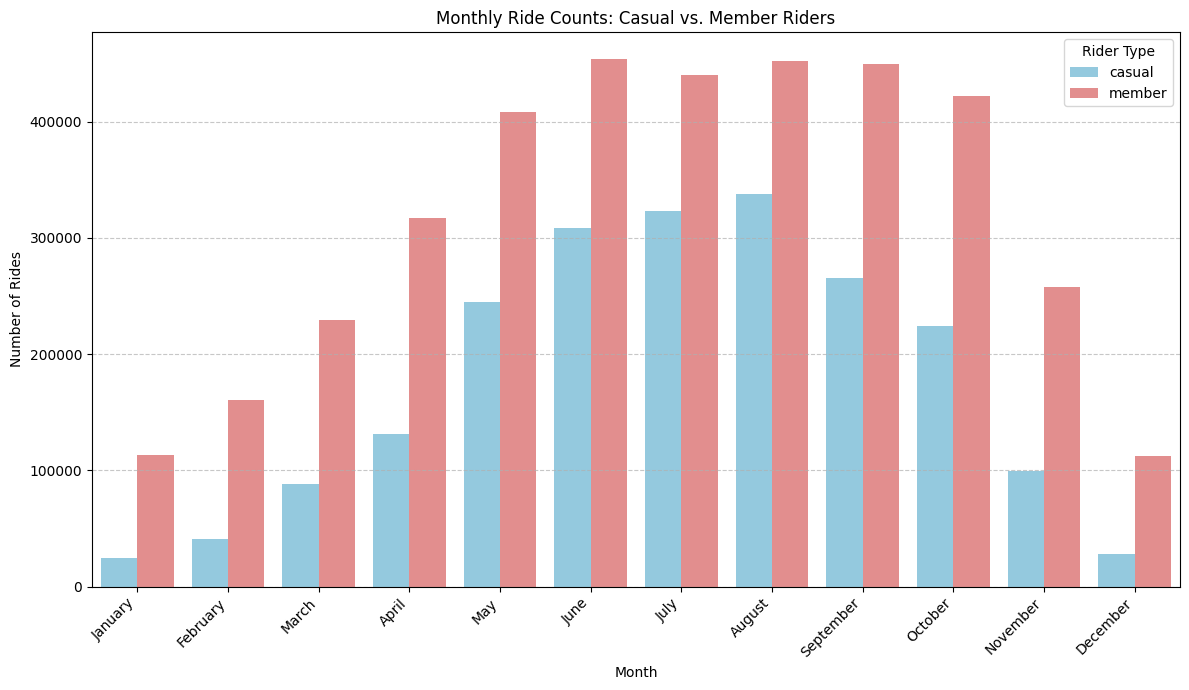

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract month number for sorting purposes, alongside month name
df_casual['start_month_num'] = df_casual['started_at'].dt.month
df_member['start_month_num'] = df_member['started_at'].dt.month

# Aggregate casual rider data by month
monthly_casual_rides = df_casual.groupby(['start_month_num', 'start_month']).size().reset_index(name='ride_count')
monthly_casual_rides['member_casual'] = 'casual'

# Aggregate member rider data by month
monthly_member_rides = df_member.groupby(['start_month_num', 'start_month']).size().reset_index(name='ride_count')
monthly_member_rides['member_casual'] = 'member'

# Combine the dataframes
monthly_rides = pd.concat([monthly_casual_rides, monthly_member_rides])

# Sort by month number to ensure correct chronological order in plot
monthly_rides = monthly_rides.sort_values(by='start_month_num')

plt.figure(figsize=(12, 7))
sns.barplot(x='start_month', y='ride_count', hue='member_casual', data=monthly_rides, palette={'casual': 'skyblue', 'member': 'lightcoral'})
plt.title('Monthly Ride Counts: Casual vs. Member Riders')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rider Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Both member and casual rides are higher in the warmer months, with over 400,000 member rides each month from May - October
# There were more member than casual rides in every month, although casual rides exceeded 300,000 in June, July and August.

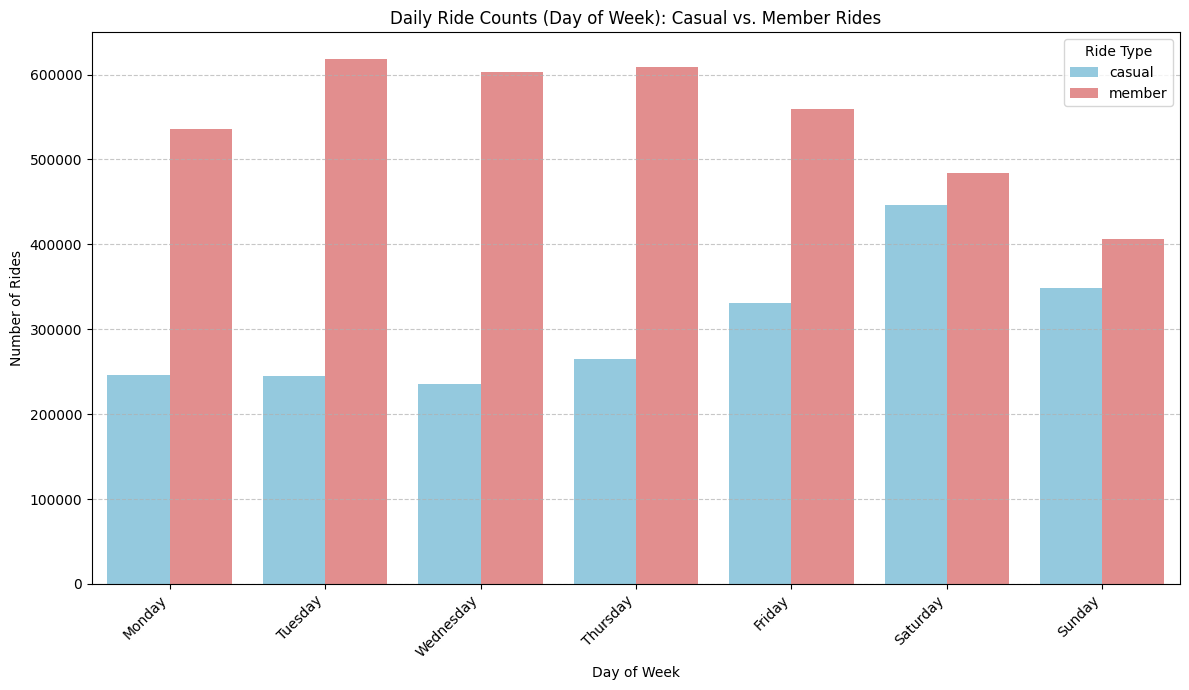

In [12]:
# Daily ride trends - days of the week

# Define the order of days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Aggregate casual rider data by day of the week
daily_casual_rides = df_casual.groupby('start_day_of_week').size().reset_index(name='ride_count')
daily_casual_rides['member_casual'] = 'casual'

# Aggregate member rider data by day of the week
daily_member_rides = df_member.groupby('start_day_of_week').size().reset_index(name='ride_count')
daily_member_rides['member_casual'] = 'member'

# Combine the dataframes
daily_rides = pd.concat([daily_casual_rides, daily_member_rides])

# Convert 'start_day_of_week' to a categorical type with the specified order
daily_rides['start_day_of_week'] = pd.Categorical(daily_rides['start_day_of_week'], categories=day_order, ordered=True)

# Sort by the categorical order
daily_rides = daily_rides.sort_values(by='start_day_of_week')

plt.figure(figsize=(12, 7))
sns.barplot(x='start_day_of_week', y='ride_count', hue='member_casual', data=daily_rides, palette={'casual': 'skyblue', 'member': 'lightcoral'})
plt.title('Daily Ride Counts (Day of Week): Casual vs. Member Rides')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ride Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Member rides were much higher MOnday-Friday than casual rides, which is strong evidence that members use the bikes to commute to and from work.
# Casual rides are highest on Saturday, closely followed by Sunday and Friday but otherwise low, a sign that casual riders use the bikes more for non-work outings.

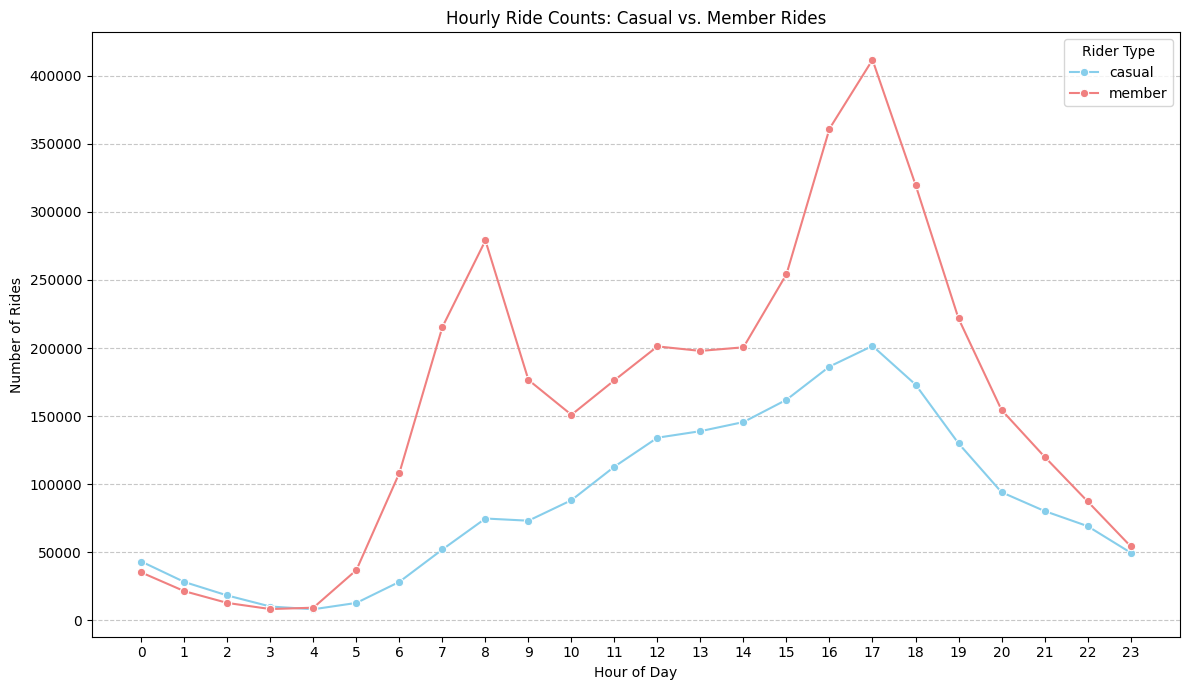

In [13]:
# Hourly ride trends - 24 hour period

# Aggregate casual ride data by hour
hourly_casual_rides = df_casual.groupby('start_hour').size().reset_index(name='ride_count')
hourly_casual_rides['member_casual'] = 'casual'

# Aggregate member ride data by hour
hourly_member_rides = df_member.groupby('start_hour').size().reset_index(name='ride_count')
hourly_member_rides['member_casual'] = 'member'

# Combine the dataframes
hourly_rides = pd.concat([hourly_casual_rides, hourly_member_rides])

plt.figure(figsize=(12, 7))
sns.lineplot(x='start_hour', y='ride_count', hue='member_casual', data=hourly_rides, marker='o', palette={'casual': 'skyblue', 'member': 'lightcoral'})
plt.title('Hourly Ride Counts: Casual vs. Member Rides')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on the x-axis
plt.legend(title='Rider Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Member rides spike sharply in peak commuting times, lending weight to the hypothesis that morning and evening transportation is a big motivator for members


In [14]:
# =============================================================================
# Ride duration
# =============================================================================

# Ensure 'started_at' and 'ended_at' in df_all are datetime objects
df_all['started_at'] = pd.to_datetime(df_all['started_at'])
df_all['ended_at'] = pd.to_datetime(df_all['ended_at'])

# Calculate ride duration for df_all
df_all['ride_duration'] = df_all['ended_at'] - df_all['started_at']

# Calculate ride duration for df_casual (already datetime)
df_casual['ride_duration'] = df_casual['ended_at'] - df_casual['started_at']

# Calculate ride duration for df_member (already datetime)
df_member['ride_duration'] = df_member['ended_at'] - df_member['started_at']

print("df_all with ride duration:")
display(df_all.head())

print("\ndf_casual with ride duration:")
display(df_casual.head())

print("\ndf_member with ride duration:")
display(df_member.head())

df_all with ride duration:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,ride_duration
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,member,0 days 00:10:38.623000
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,member,0 days 00:08:56.902000
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,member,0 days 00:26:00.857000
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,member,0 days 00:10:33.648000
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,member,0 days 00:13:21.474000



df_casual with ride duration:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,start_month,start_day_of_week,start_hour,start_month_num,ride_duration
7,A19B1B6B9C62B115,classic_bike,2025-07-27 13:43:30.714,2025-07-27 13:59:57.433,Millennium Park,CHI01742,Wabash Ave & 9th St,CHI00448,casual,July,Sunday,13,7,0 days 00:16:26.719000
8,45CBB32AC2C79791,classic_bike,2025-07-23 20:14:04.150,2025-07-23 20:24:59.733,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,casual,July,Wednesday,20,7,0 days 00:10:55.583000
9,EB5F7E1F95940534,classic_bike,2025-07-23 21:03:15.690,2025-07-23 21:23:13.370,Theater on the Lake,CHI00420,Racine Ave & Belmont Ave,CHI00411,casual,July,Wednesday,21,7,0 days 00:19:57.680000
10,AFC2A8F99FCEAE60,classic_bike,2025-07-05 18:43:59.471,2025-07-05 19:11:08.959,Western Ave & Division St,CHI00375,Damen Ave & Cullerton St,CHI00267,casual,July,Saturday,18,7,0 days 00:27:09.488000
11,E6422A2EBAF87EB4,classic_bike,2025-07-09 19:28:24.973,2025-07-09 20:09:18.096,Theater on the Lake,CHI00420,Sheridan Rd & Loyola Ave,CHI00752,casual,July,Wednesday,19,7,0 days 00:40:53.123000



df_member with ride duration:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,start_month,start_day_of_week,start_hour,start_month_num,ride_duration
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,member,July,Saturday,17,7,0 days 00:10:38.623000
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,member,July,Tuesday,13,7,0 days 00:08:56.902000
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,member,July,Thursday,16,7,0 days 00:26:00.857000
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,member,July,Thursday,9,7,0 days 00:10:33.648000
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,member,July,Wednesday,18,7,0 days 00:13:21.474000


In [15]:
# Ride duration continued

# Remove rides with duration <= 0 (invalid rides)
df_all = df_all[df_all['ride_duration'].dt.total_seconds() > 0]
df_casual = df_casual[df_casual['ride_duration'].dt.total_seconds() > 0]
df_member = df_member[df_member['ride_duration'].dt.total_seconds() > 0]

# Average, min, max, median for ride duration across all rides, within casual riders and within member riders

print(f"The average ride duration for all rides is {round(df_all['ride_duration'].mean().total_seconds() / 60, 2)} minutes.")
print(f"The average ride duration for casual riders is {round(df_casual['ride_duration'].mean().total_seconds() / 60, 2)} minutes.")
print(f"The average ride duration for member riders is {round(df_member['ride_duration'].mean().total_seconds() / 60, 2)} minutes.")

print(f"The median ride duration for all rides is {round(df_all['ride_duration'].median().total_seconds() / 60, 2)} minutes.")
print(f"The median ride duration for casual riders is {round(df_casual['ride_duration'].median().total_seconds() / 60, 2)} minutes.")
print(f"The median ride duration for member riders is {round(df_member['ride_duration'].median().total_seconds() / 60, 2)} minutes.")

print(f"The minimum ride duration for all rides is {round(df_all['ride_duration'].min().total_seconds() / 60, 2)} minutes.")
print(f"The minimum ride duration for casual riders is {round(df_casual['ride_duration'].min().total_seconds() / 60, 2)} minutes.")
print(f"The minimum ride duration for member riders is {round(df_member['ride_duration'].min().total_seconds() / 60, 2)} minutes.")

print(f"The maximum ride duration for all rides is {round(df_all['ride_duration'].max().total_seconds() / 60, 2)} minutes.")
print(f"The maximum ride duration for casual riders is {round(df_casual['ride_duration'].max().total_seconds() / 60, 2)} minutes.")
print(f"The maximum ride duration for member riders is {round(df_member['ride_duration'].max().total_seconds() / 60, 2)} minutes.")

# Both the average and median casual ride is longer than the member ride

The average ride duration for all rides is 15.77 minutes.
The average ride duration for casual riders is 21.73 minutes.
The average ride duration for member riders is 12.46 minutes.
The median ride duration for all rides is 9.37 minutes.
The median ride duration for casual riders is 11.16 minutes.
The median ride duration for member riders is 8.59 minutes.
The minimum ride duration for all rides is 0.0 minutes.
The minimum ride duration for casual riders is 0.0 minutes.
The minimum ride duration for member riders is 0.0 minutes.
The maximum ride duration for all rides is 1559.95 minutes.
The maximum ride duration for casual riders is 1559.95 minutes.
The maximum ride duration for member riders is 1559.9 minutes.


In [16]:
# Verifying the max numbers aren't a glitch because 1 day+ looks too high

max_duration_casual = df_casual['ride_duration'].max()
max_duration_member = df_member['ride_duration'].max()

print(f"Maximum ride duration for casual riders: {max_duration_casual}")
print(f"Maximum ride duration for member riders: {max_duration_member}")

# Now, let's find and display details for the maximum member ride
tolerance = pd.Timedelta(seconds=1)
long_member_rides = df_member[
    (df_member['ride_duration'] >= (max_duration_member - tolerance)) &
    (df_member['ride_duration'] <= (max_duration_member + tolerance))
].copy()

# Now, let's find and display details for the maximum casual ride
tolerance = pd.Timedelta(seconds=1)
long_casual_rides = df_casual[
    (df_casual['ride_duration'] >= (max_duration_casual - tolerance)) &
    (df_casual['ride_duration'] <= (max_duration_casual + tolerance))
].copy()

print(f"\nFound {len(long_member_rides)} rides with duration close to the maximum for member riders.")
display(long_member_rides[['ride_id', 'started_at', 'ended_at', 'ride_duration', 'member_casual']].head(10))

print(f"\nFound {len(long_casual_rides)} rides with duration close to the maximum for casual riders.")
display(long_casual_rides[['ride_id', 'started_at', 'ended_at', 'ride_duration', 'member_casual']].head(10))

Maximum ride duration for casual riders: 1 days 01:59:57.011000
Maximum ride duration for member riders: 1 days 01:59:54.221000

Found 1 rides with duration close to the maximum for member riders.


,ride_id,started_at,ended_at,ride_duration,member_casual
3895510,250556580DD308BE,2026-03-07 23:51:38.812,2026-03-09 01:51:33.033,1 days 01:59:54.221000,member



Found 1 rides with duration close to the maximum for casual riders.


,ride_id,started_at,ended_at,ride_duration,member_casual
3818349,C82393BDD3070D5D,2026-03-07 16:07:09.988,2026-03-08 18:07:06.999,1 days 01:59:57.011000,casual


In [17]:
# Duration patterns by day and month, in case longer casual rides on weekends and summer

# Average duration patterns by month for casual vs member

df_casual_monthly_duration = df_casual.groupby('start_month')['ride_duration'].mean()
df_member_monthly_duration = df_member.groupby('start_month')['ride_duration'].mean()

print("\nAverage Casual Monthly Ride Duration:")
display(df_casual_monthly_duration.head(12))

print("\nAverage Member Monthly Ride Duration:")
display(df_member_monthly_duration.head(12))



Average Casual Monthly Ride Duration:


,ride_duration
start_month,
April,0 days 00:19:26.644748201
August,0 days 00:23:36.497981300
December,0 days 00:16:58.125726130
February,0 days 00:16:53.540788842
January,0 days 00:17:40.321086095
July,0 days 00:24:23.692250473
June,0 days 00:21:43.510855014
March,0 days 00:20:05.316396152
May,0 days 00:21:59.254593082



Average Member Monthly Ride Duration:


,ride_duration
start_month,
April,0 days 00:11:33.104331251
August,0 days 00:13:05.698708670
December,0 days 00:11:55.112810306
February,0 days 00:10:50.278912566
January,0 days 00:12:44.314539454
July,0 days 00:13:21.164285463
June,0 days 00:12:48.971608471
March,0 days 00:11:21.354909279
May,0 days 00:12:31.275674716


In [18]:
# Average duration patterns by day for casual vs member

df_casual_day_duration = df_casual.groupby('start_day_of_week')['ride_duration'].mean()
df_member_day_duration = df_member.groupby('start_day_of_week')['ride_duration'].mean()

print("\nAverage Casual Day Ride Duration:")
display(df_casual_day_duration.head(12))

print("\nAverage Member Day Ride Duration:")
display(df_member_day_duration.head(12))



Average Casual Day Ride Duration:


,ride_duration
start_day_of_week,
Friday,0 days 00:21:27.875421943
Monday,0 days 00:21:38.636688203
Saturday,0 days 00:24:20.552712276
Sunday,0 days 00:25:17.489395281
Thursday,0 days 00:19:01.091159225
Tuesday,0 days 00:18:40.978121597
Wednesday,0 days 00:18:09.232563875



Average Member Day Ride Duration:


,ride_duration
start_day_of_week,
Friday,0 days 00:12:24.160877239
Monday,0 days 00:12:11.137703261
Saturday,0 days 00:13:42.369391978
Sunday,0 days 00:13:41.343150654
Thursday,0 days 00:11:59.784073962
Tuesday,0 days 00:11:57.381772920
Wednesday,0 days 00:11:56.192040179


In [19]:
# =============================================================================
# Preference for electric vs. classic bikes
# =============================================================================

df_casual_biketype = df_casual.groupby('rideable_type')['ride_id'].count()
df_member_biketype = df_member.groupby('rideable_type')['ride_id'].count()

print("\nCasual Rides Bike Type Distribution:")
display(df_casual_biketype)

print("\nMember Rides Bike Type Distribution:")
display(df_member_biketype)

# More rides were on electric bikes over classic among both members and casual rides


Casual Rides Bike Type Distribution:


,ride_id
rideable_type,
classic_bike,634916
electric_bike,1481697



Member Rides Bike Type Distribution:


,ride_id
rideable_type,
classic_bike,1284925
electric_bike,2530747


In [20]:
# Most common starting locations

df_casual_start_locations = df_casual.groupby(['start_station_name'])['ride_id'].count().reset_index(name='ride_count').sort_values(by='ride_count', ascending=False)
df_member_start_locations = df_member.groupby(['start_station_name'])['ride_id'].count().reset_index(name='ride_count').sort_values(by='ride_count', ascending=False)

print("\nCasual Rides Start Locations by Ride Count:")
display(df_casual_start_locations.head(10))

print("\nMember Rides Start Locations by Ride Count:")
display(df_member_start_locations.head(10))


Casual Rides Start Locations by Ride Count:


,start_station_name,ride_count
846,Navy Pier,46800
338,DuSable Lake Shore Dr & Monroe St,32842
790,Michigan Ave & Oak St,22883
339,DuSable Lake Shore Dr & North Blvd,20209
798,Millennium Park,18519
1589,Shedd Aquarium,17229
1701,Theater on the Lake,16232
342,Dusable Harbor,15176
784,Michigan Ave & 8th St,10928
818,Montrose Harbor,10571



Member Rides Start Locations by Ride Count:


,start_station_name,ride_count
153,Canal St & Madison St,22808
1673,State St & Chicago Ave,21186
238,Clinton St & Madison St,19893
1769,Wells St & Concord Ln,19531
1770,Wells St & Elm St,19512
242,Clinton St & Washington Blvd,19434
236,Clinton St & Jackson Blvd,19281
209,Clark St & Elm St,18208
1773,Wells St & Huron St,18207
585,Kingsbury St & Kinzie St,16995
